# Exploratory Data Analysis: Fashion Product Images (Small)

**Dataset:** [Fashion Product Images (Small)](https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small) (Kaggle, author `paramaggarwal`), ~44,441 product images with metadata in `styles.csv`.

**Goal:** select a focused subset of garment categories, clean and validate the data (missing/corrupt images, inconsistent labels), and produce a clean `id` + `articleType` CSV to feed the training pipeline for the Wardrobe Selector garment classifier.


## 0. Load Dataset

In [1]:
import pandas as pd
import numpy as np

# Path resolves relative to notebooks/, where this file lives
file_path = "../data/datasets/paramaggarwal/fashion-product-images-small/versions/1/styles.csv"
df = pd.read_csv(file_path)

df.head()


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,NaN,NaN
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,NaN,NaN
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,NaN,NaN
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,NaN,NaN
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,NaN,NaN


## 1. Helper Functions

Small set of reusable EDA helpers, used throughout this notebook for a consistent first look at the data (shape, dtypes, nulls, distributions).

In [2]:
def eda_first_look(df):
    print("\n=== FIRST LOOK ===")
    print("Columns:", df.columns)
    print("--------------------------------")
    print("Shape:", df.shape)
    print("--------------------------------")
    print("\nDtypes:\n", df.dtypes)
    print("--------------------------------")
    print("\nInfo:\n", df.info())
    print("--------------------------------")

def eda_data_quality(df):
    print("\n=== DATA QUALITY ===")
    print("\nNull values:\n", df.isnull().sum())
    print("--------------------------------")
    print("\nNull values(%):\n", df.isnull().sum()*100/len(df))
    print("--------------------------------")
    print("\nDuplicated values:", df.duplicated().sum())
    print("--------------------------------")
    print("\nUnique values per column:\n", df.nunique())
    print("--------------------------------")

def eda_numeric(df):
    print("\n=== NUMERIC SUMMARY ===")
    print("\nDescription\n", df.describe())
    print("--------------------------------")
    print("\nQuantitative columns:\n", df.select_dtypes(include=[np.number]).columns)
    print("--------------------------------")
    print("\nSkewness:\n", df.select_dtypes(include=[np.number]).skew())
    print("--------------------------------")
    print("\nCorrelation:\n", df.corr(numeric_only=True))
    print("--------------------------------")

def eda_categorical(df):
    print("\n=== CATEGORICAL SUMMARY ===")
    cat_cols = df.select_dtypes(include=['object']).columns
    print("\nCategorical columns:\n", cat_cols)
    print("--------------------------------")

    for col in cat_cols:
        print("\nColumn: " + col + "\n")
        print("--------------------------------")
        print("Unique values: ", df[col].unique())
        print("--------------------------------")
        print("Frequency:\n", df[col].value_counts())
        print("--------------------------------")
        print("Mode:\n", df[col].mode())
        print("--------------------------------")


def eda_univariate(df):
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(include=['object']).columns
 
    # --- Numeric ---
    print("\n=== UNIVARIATE: NUMERIC ===")
    print("\nQuantitative columns:\n", num_cols)
    print("--------------------------------")
    print("\nDescription:\n", df[num_cols].describe())
    print("--------------------------------")
    print("\nSkewness:\n", df[num_cols].skew())
    print("--------------------------------")
 
    # --- Categorical ---
    print("\n=== UNIVARIATE: CATEGORICAL ===")
    print("\nCategorical columns:\n", cat_cols)
    print("--------------------------------")
 
 
def eda_bivariate(df, target=None):
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(include=['object']).columns
 
    # --- Numeric vs numeric ---
    print("\n=== BIVARIATE: NUMERIC vs NUMERIC ===")
    print("\nCorrelation matrix:\n", df[num_cols].corr())
    print("--------------------------------")
 
    # --- Categorical vs target (if specified) ---
    if target is not None and target in df.columns:
        print(f"\n=== BIVARIATE: CATEGORICAL vs {target} ===")
        for col in cat_cols:
            if col == target:
                continue
            print(f"\nCrosstab: {col} vs {target}\n")
            print(pd.crosstab(df[col], df[target]))
            print("--------------------------------")
 
        # --- Numeric vs target, if target is categorical ---
        if target in cat_cols.tolist():
            print(f"\n=== BIVARIATE: NUMERIC vs {target} ===")
            for col in num_cols:
                print(f"\n{col} grouped by {target}:\n")
                print(df.groupby(target)[col].agg(["mean", "median", "std", "count"]))
                print("--------------------------------")


## 2. Initial Exploration

### Shape, dtypes & structure

In [3]:
eda_first_look(df)


=== FIRST LOOK ===
Columns: Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName',
       'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')
--------------------------------
Shape: (44446, 12)
--------------------------------

Dtypes:
 id                      int64
gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
Unnamed: 10            object
Unnamed: 11            object
dtype: object
--------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44446 entries, 0 to 44445
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44446 non-null  int64  
 1   gender 

### Data quality: nulls & duplicates

Two columns (`Unnamed: 10`, `Unnamed: 11`) show up as almost entirely null, likely a CSV parsing artifact rather than real data. Addressed in the cleaning section below.

In [4]:
eda_data_quality(df)


=== DATA QUALITY ===

Null values:
 id                        0
gender                    0
masterCategory            0
subCategory               0
articleType               0
baseColour               15
season                   21
year                      1
usage                   317
productDisplayName        7
Unnamed: 10           44424
Unnamed: 11           44444
dtype: int64
--------------------------------

Null values(%):
 id                     0.000000
gender                 0.000000
masterCategory         0.000000
subCategory            0.000000
articleType            0.000000
baseColour             0.033749
season                 0.047248
year                   0.002250
usage                  0.713225
productDisplayName     0.015749
Unnamed: 10           99.950502
Unnamed: 11           99.995500
dtype: float64
--------------------------------

Duplicated values: 0
--------------------------------

Unique values per column:
 id                    44446
gender              

### Numeric summary

In [5]:
eda_numeric(df)


=== NUMERIC SUMMARY ===

Description
                  id          year
count  44446.000000  44445.000000
mean   29692.631350   2012.805940
std    17048.234982      2.126401
min     1163.000000   2007.000000
25%    14770.250000   2011.000000
50%    28609.500000   2012.000000
75%    44678.750000   2015.000000
max    60000.000000   2019.000000
--------------------------------

Quantitative columns:
 Index(['id', 'year'], dtype='object')
--------------------------------

Skewness:
 id      0.105457
year    0.924869
dtype: float64
--------------------------------

Correlation:
             id      year
id    1.000000  0.415195
year  0.415195  1.000000
--------------------------------


### Categorical columns overview

In [6]:
eda_categorical(df)


=== CATEGORICAL SUMMARY ===

Categorical columns:
 Index(['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour',
       'season', 'usage', 'productDisplayName', 'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')
--------------------------------

Column: gender

--------------------------------
Unique values:  ['Men' 'Women' 'Boys' 'Girls' 'Unisex']
--------------------------------
Frequency:
 gender
Men       22165
Women     18632
Unisex     2164
Boys        830
Girls       655
Name: count, dtype: int64
--------------------------------
Mode:
 0    Men
Name: gender, dtype: object
--------------------------------

Column: masterCategory

--------------------------------
Unique values:  ['Apparel' 'Accessories' 'Footwear' 'Personal Care' 'Free Items'
 'Sporting Goods' 'Home']
--------------------------------
Frequency:
 masterCategory
Apparel           21400
Accessories       11289
Footwear           9222
Personal Care      2404
Free Items          105
Sporting Goods  

## 3. Category Selection

The raw dataset has 143 distinct `articleType` values, most of them accessories/beauty products out of scope for a garment classifier. Full distribution below, used to pick a focused subset.

In [7]:
print(df["articleType"].value_counts().to_string())

articleType
Tshirts                      7070
Shirts                       3217
Casual Shoes                 2846
Watches                      2542
Sports Shoes                 2036
Kurtas                       1844
Tops                         1762
Handbags                     1759
Heels                        1323
Sunglasses                   1073
Wallets                       936
Flip Flops                    916
Sandals                       897
Briefs                        849
Belts                         813
Backpacks                     724
Socks                         686
Formal Shoes                  637
Perfume and Body Mist         614
Jeans                         609
Shorts                        547
Trousers                      530
Flats                         500
Bra                           477
Dresses                       464
Sarees                        427
Earrings                      417
Deodorant                     347
Nail Polish                   329
Li

### Selecting the 14 target categories

In [8]:
# 14 garment categories, chosen from the raw articleType values above (see markdown note)
categories = ["Tshirts","Shirts","Tops","Jeans","Sweatshirts","Sweaters","Jackets","Dresses","Skirts","Shorts","Track Pants","Casual Shoes", "Sports Shoes", "Formal Shoes"]

categories_count = df[df["articleType"].isin(categories)]["articleType"].value_counts()
categories_count

articleType
Tshirts         7070
Shirts          3217
Casual Shoes    2846
Sports Shoes    2036
Tops            1762
Formal Shoes     637
Jeans            609
Shorts           547
Dresses          464
Track Pants      304
Sweatshirts      285
Sweaters         277
Jackets          258
Skirts           128
Name: count, dtype: int64

In [9]:
categories_count.sum()


np.int64(20440)

## 4. Cleaning

### Dropping unused columns

`Unnamed: 10` and `Unnamed: 11` are >99.9% null with no documented meaning, dropped as CSV parsing noise.

In [10]:
# Unnamed: 10 / Unnamed: 11 are >99.9% null, CSV parsing noise, not real columns
df = df.drop(['Unnamed: 10', 'Unnamed: 11'], axis=1)

In [11]:
df.columns

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')

### Filtering to target categories

In [12]:
df_filtered = df[df["articleType"].isin(categories)]
df_filtered.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt


In [13]:
df_filtered.shape

(20440, 10)

### Verifying image files exist

This dataset has a known quirk: `styles.csv` can contain rows whose `id` has no matching `.jpg` in `images/`. Checked explicitly rather than assumed, since a missing file would otherwise only surface later as a crash in the training `DataLoader`.

In [14]:
import os

targets_dir = "../data/datasets/paramaggarwal/fashion-product-images-small/versions/1/images"

missing_targets = []

# Known dataset quirk: some ids in styles.csv have no matching .jpg file
for target_id in df_filtered["id"]:
    path_exists = os.path.exists(f"{targets_dir}/{target_id}.jpg")
    if not path_exists:
        missing_targets.append(target_id)

print(len(missing_targets))



4


In [15]:
len(df_filtered)

20440

In [16]:
# Drop the 4 rows with no matching image file
df_filtered = df_filtered[~df_filtered["id"].isin(missing_targets)]

In [17]:
len(df_filtered)

20436

### Checking `subCategory` consistency

Considered deriving a `subCategory` (and later, an outfit "role": top/bottom/outer/dress/shoes) directly from `articleType`. Grouping by `articleType` shows the mapping isn't always 1:1, e.g. some `Tshirts` rows are tagged `Belts`, some `Dresses` rows are tagged `Topwear`. This is mislabeled source data, not a real multi-category case, so it's handled with a manual, curated mapping later (Phase 3) rather than trusted from this column.

In [18]:
# Checking if articleType maps 1:1 to subCategory before trusting it as a derived field
df_filtered.groupby("articleType")["subCategory"].unique()

articleType
Casual Shoes                                   [Shoes]
Dresses                               [Dress, Topwear]
Formal Shoes                                   [Shoes]
Jackets                                      [Topwear]
Jeans                                     [Bottomwear]
Shirts                                       [Topwear]
Shorts          [Bottomwear, Loungewear and Nightwear]
Skirts                                    [Bottomwear]
Sports Shoes                                   [Shoes]
Sweaters                                     [Topwear]
Sweatshirts                                  [Topwear]
Tops                                         [Topwear]
Track Pants                               [Bottomwear]
Tshirts                               [Topwear, Belts]
Name: subCategory, dtype: object

### Final column selection

The classifier is single-task (predicts `articleType` only). A model only learns whatever target it's trained on, so keeping extra metadata columns (`gender`, `season`, `productDisplayName`, etc.) around wouldn't add any predictive capability. Only `id` (to build the image path) and `articleType` (the label) are needed going forward.

In [19]:
# Only id (to build the image path) and articleType (the label) are needed for training
columns_to_keep = ["id", "articleType"]

df_final = df_filtered[columns_to_keep]

## 5. Visual Inspection

Sampling 2 images per category as a manual sanity check, catches obviously mislabeled or unexpected images that summary statistics alone wouldn't reveal.

Tshirts


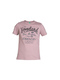

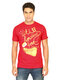

Shirts


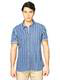

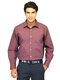

Tops


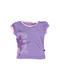

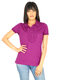

Jeans


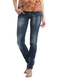

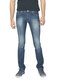

Sweatshirts


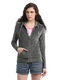

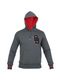

Sweaters


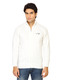

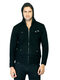

Jackets


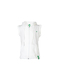

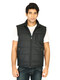

Dresses


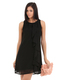

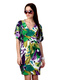

Skirts


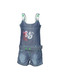

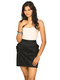

Shorts


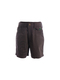

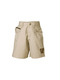

Track Pants


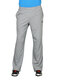

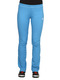

Casual Shoes


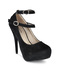

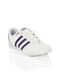

Sports Shoes


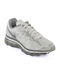

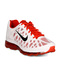

Formal Shoes


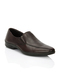

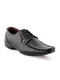

In [20]:
from PIL import Image

for category in categories:
    category_data = df_final[df_final["articleType"].isin([category])]

    if category_data.empty:
        print(f"No data for: {category}")
        continue

    print(category)

    # Random sample of 2 rows, not a fixed slice, so re-running shows different images
    samples = category_data.sample(2)

    for _, sample in samples.iterrows():
        image_path = f'{targets_dir}/{sample["id"]}.jpg'

        display(Image.open(image_path))

### Verifying image integrity

Not just that files exist, but that they can actually be opened. Catches truncated/corrupt files before they break the training `DataLoader`.

In [21]:
from PIL import Image, UnidentifiedImageError

corrupt_images = []

for image_id in df_final["id"]:
    image_path = f"{targets_dir}/{image_id}.jpg"

    try:
        img = Image.open(image_path)
        # verify() checks file integrity without decoding full pixel data, cheap on 20k+ files
        img.verify()

    except (UnidentifiedImageError, OSError):
        corrupt_images.append(image_id)

print(f"Total corrupted images: {len(corrupt_images)}")

Total corrupted images: 0


## 6. Export Clean Dataset

0 corrupted images found, so the final export below is safe to run directly on `df_final` (already excludes the 4 rows with missing image files).

In [22]:
# Final clean export consumed by the training pipeline (src/data.py)
path = "../data/clean_data"
df_final.to_csv(f'{path}/clean_df.csv', index=False)

In [23]:
new_df_path = "../data/clean_data/clean_df.csv"
clean_df = pd.read_csv(new_df_path)
clean_df.shape

(20436, 2)

## Summary

- Selected **14 garment categories** out of 143 raw `articleType` values (7,070 to 128 images per class, ~55:1 imbalance, handled later via class-weighted loss, not resampling, to avoid discarding data needed for training a CNN from scratch).
- Dropped 2 near-empty junk columns (`Unnamed: 10`, `Unnamed: 11`).
- Found and excluded **4 rows** with no matching image file (known dataset quirk).
- Verified **0 corrupted images** among the remaining 20,436.
- Found inconsistent `subCategory` labels (e.g. mislabeled `Tshirts` mapped to `Belts`), decided not to trust that column; will use a manual curated mapping for outfit roles in Phase 3 instead.
- Exported the clean subset to `data/clean_data/clean_df.csv`: **20,436 rows**, columns `id` + `articleType` only.